# DINO 1° forward: the 200-year spin-up from rest under the 2026-09-10 production configuration

Run **31203**: 200 yr (73 200 d, 9 619 200 steps at Δt = 1800 s) from rest under the live `input/data` decided on 2026-09-10 — the reference viscosity files (`dino_viscAhD.bin`, DINO's A_h = ½·U_v·Δx with U_v = 0.27 m s⁻¹) plus `viscAhReMax = 2.`, the flux-limited DST3 tracer advection (scheme 33) with **explicit** vertical advection, `diffKrT = diffKrS = 1.2e-5`, GM/Redi on. It ran 31 h 39 min on 27 ranks (2026-09-10 03:23 to 2026-09-11 11:02 CDT) and ended normally; it is filed under `runs/forward/spinup_200yr_viscRef_ReMax2/` and its year-180 pickup (iteration 3 162 240) is what the chained production adjoint 31204 reads.

Compared against **30983**, the 200-yr spin-up at twice DINO's viscosity (`dino_viscAhD_2p00.bin`, no Reynolds cap, implicit vertical advection) that was the production state until 2026-09-09 and still supplies the year-170 pickup every kappa-ensemble leg starts from. Also read: **31205**, the reference kappa leg (10 yr from 30983's year-170 pickup under the new configuration), whose year-180 state is where the early production adjoint 31206 and the ensemble live — how far that state is from this spin-up's own year-180 state is the last question this notebook answers.

| run | what | years | pickups |
| --- | --- | --- | --- |
| 31203 | this spin-up: reference viscosity + `viscAhReMax=2`, scheme 33, explicit vertical advection | 0–200 | monthly, 2 402 |
| 30983 | the 2× spin-up (`visc2x`), implicit vertical advection | 0–200 | monthly, 2 402 |
| 31205 | reference kappa leg from 30983's year 170 under the new configuration | 170–180 | year 180 only |
| 31256 | 10 yr from rest under the live namelist, same executable: the forward reproducibility check | 0–10 | monthly (to be deleted) |

Diagnostics: `dynDiag` (THETA, SALT, UVEL, VVEL, WVEL, …) and `surfDiag` (ETAN, MXLDEPTH, …) every 30.5 d, `%MON` every 30.5 d. Figures go to `analysis/spinup_200yr_viscRef_ReMax2/figures/` on scratch (a product of several runs, so not inside either run directory).

In [1]:
import os, glob, json, filecmp, warnings, collections
import numpy as np, xarray as xr, xmitgcm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
SCRATCH = '/scratch2/tshahriar/DINO_1deg_outputs'; RUNS = SCRATCH + '/runs/forward'
OUT = SCRATCH + '/analysis/spinup_200yr_viscRef_ReMax2'; FIG_DIR = OUT + '/figures'; os.makedirs(FIG_DIR, exist_ok=True)
NEW, OLD, LEG = 'viscRef+ReMax2 (31203)', 'visc2x (30983)', 'REF leg from 2x yr 170 (31205)'
run_dir = {NEW: RUNS + '/spinup_200yr_viscRef_ReMax2/DINO_1deg_frd_200yr_from_rest_viscRef_ReMax2_run31203',
           OLD: RUNS + '/spinup_200yr_visc2x/DINO_1deg_frd_200yr_from_rest_visc2x_run30983',
           LEG: RUNS + '/kappa_v_ensemble_ReMax2_approxAdv/DINO_1deg_frd_10yr_REF_ReMax2_run31205'}
for p in run_dir.values(): assert os.path.isdir(p), p
COL = {NEW: 'C3', OLD: 'C0', LEG: 'C2'}
DT = 1800.; STEPS_PER_YR = 48 * 366
def years(its): return np.asarray(its) / STEPS_PER_YR
def mon(p):
    b = collections.OrderedDict(); cur = None
    for l in open(p):
        if '%MON' not in l: continue
        s = l.split('%MON', 1)[1].strip()
        if s.startswith('time_tsnumber'): cur = int(s.split('=')[1]); b[cur] = {}
        elif cur is not None and '=' in s:
            k, v = s.split('=', 1)
            try: b[cur][k.strip()] = float(v)
            except ValueError: pass
    return b
def iters_of(r, prefix='dynDiag'): return sorted(int(os.path.basename(f).split('.')[1]) for f in glob.glob(f'{r}/{prefix}.*.meta'))
def annual(y, v):
    n = len(v) // 12; return y[:n * 12].reshape(n, 12).mean(1), v[:n * 12].reshape(n, 12).mean(1)

## 1. Monitor statistics over the 200 years

Volume-mean and extreme temperature, salinity and kinetic energy from `%MON` (every 30.5 d), both spin-ups. The drift over the last 50 years says how close each is to equilibrium; the extremes say whether the tracers stay inside the forcing range.

quantity               run                         yr 0-10  yr 90-100 yr 140-150 yr 190-200   drift/decade (150-200)
volume-mean T [°C]     viscRef+ReMax2 (31203)        5.537      5.648       5.81      5.958                   0.0293
volume-mean T [°C]     visc2x (30983)                5.526      5.573      5.737      5.891                   0.0305
volume-mean S          viscRef+ReMax2 (31203)        35.26      35.39      35.44      35.48                   0.0084
volume-mean S          visc2x (30983)                35.26      35.41      35.47      35.53                   0.0106
mean KE [m² s⁻²]       viscRef+ReMax2 (31203)    0.0003328  0.0003231  0.0003212  0.0003199                -2.75e-07
mean KE [m² s⁻²]       visc2x (30983)            0.0002998  0.0002996  0.0002967  0.0002944                -4.87e-07
max KE [m² s⁻²]        viscRef+ReMax2 (31203)       0.2706     0.2947     0.2958      0.297                 0.000222
max KE [m² s⁻²]        visc2x (30983)               0.2797     0

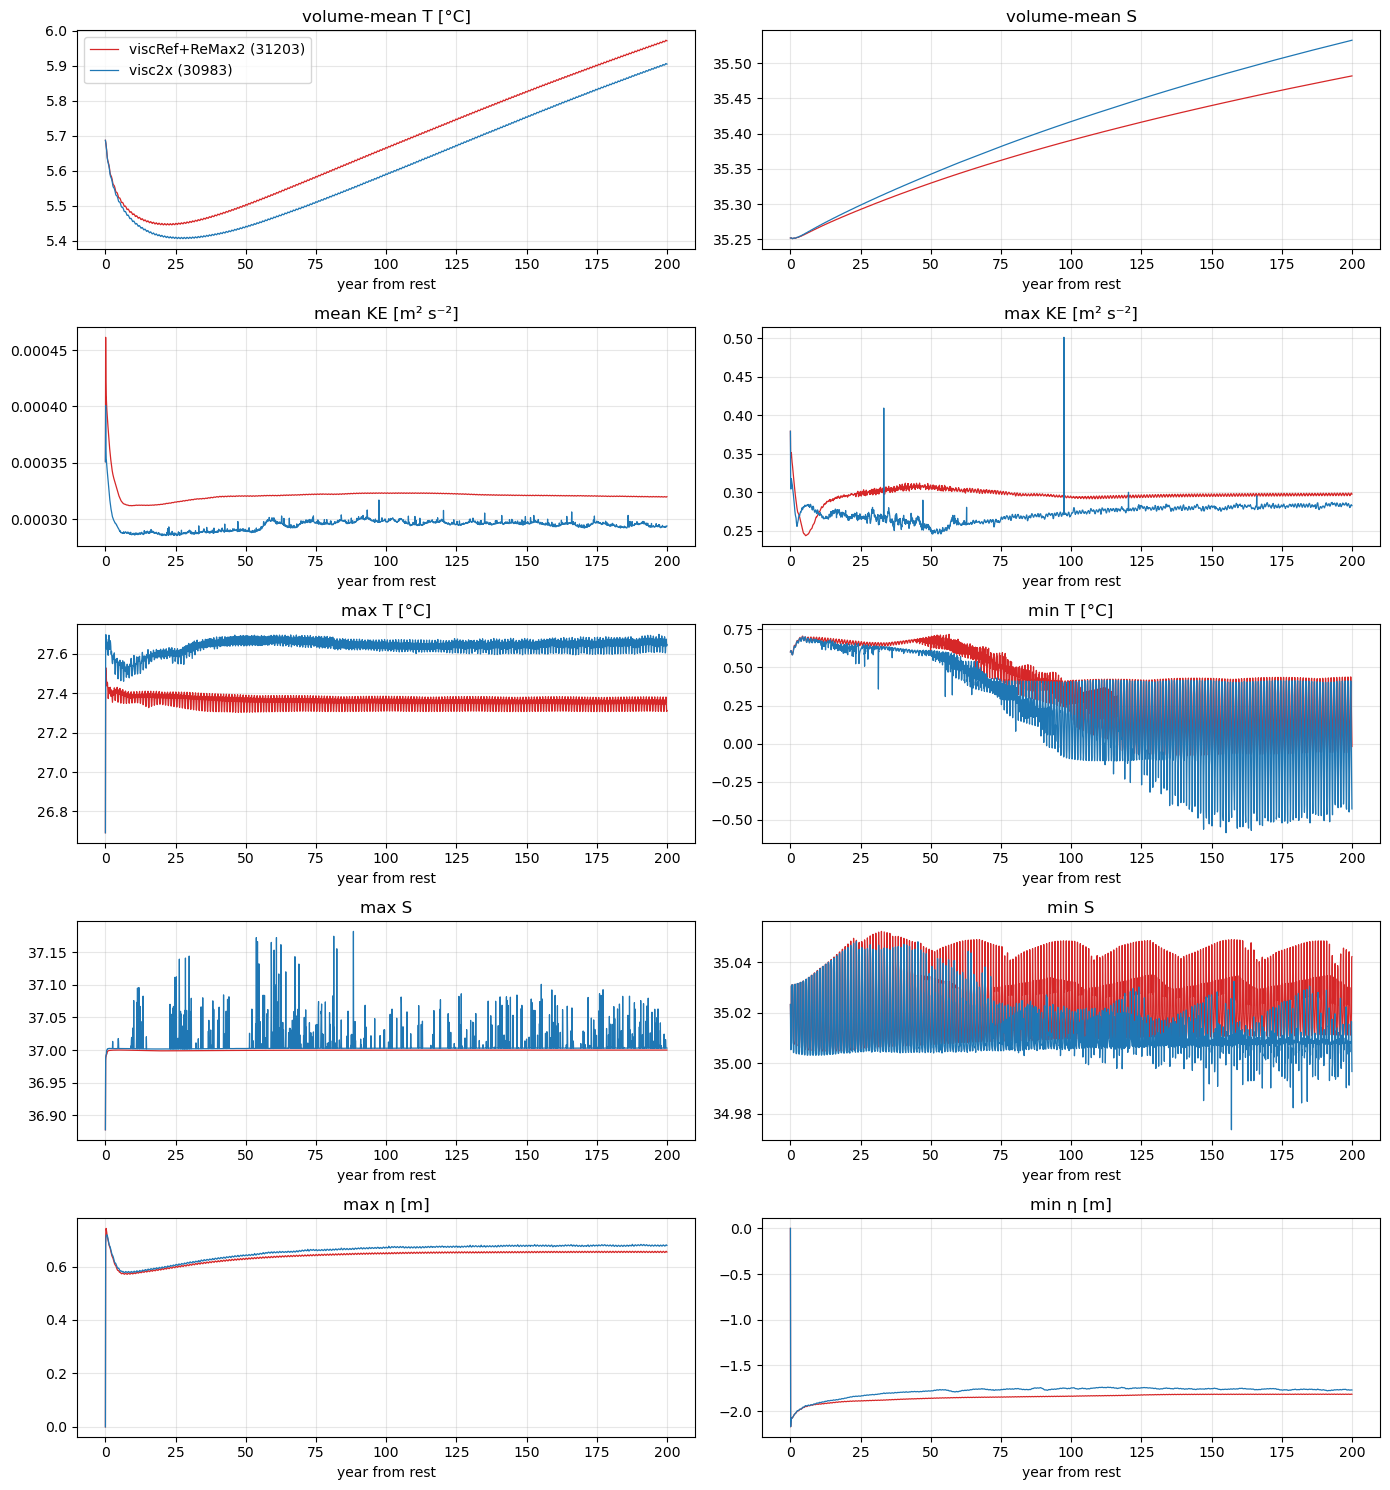

In [2]:
M = {k: mon(run_dir[k] + '/STDOUT.0000') for k in (NEW, OLD)}
def series(m, key):
    it = np.array(list(m)); return it / STEPS_PER_YR, np.array([m[i].get(key, np.nan) for i in m])
keys = [('dynstat_theta_mean', 'volume-mean T [°C]'), ('dynstat_salt_mean', 'volume-mean S'), ('ke_mean', 'mean KE [m² s⁻²]'), ('ke_max', 'max KE [m² s⁻²]'),
        ('dynstat_theta_max', 'max T [°C]'), ('dynstat_theta_min', 'min T [°C]'), ('dynstat_salt_max', 'max S'), ('dynstat_salt_min', 'min S'),
        ('dynstat_eta_max', 'max η [m]'), ('dynstat_eta_min', 'min η [m]')]
fig, axs = plt.subplots(5, 2, figsize=(14, 15))
for ax, (key, lab) in zip(axs.flat, keys):
    for k, m in M.items():
        t, v = series(m, key); ax.plot(t, v, lw=0.9, color=COL[k], label=k)
    ax.set_title(lab); ax.grid(alpha=.3); ax.set_xlabel('year from rest')
axs[0, 0].legend(); fig.tight_layout(); fig.savefig(FIG_DIR + '/monitor_series_31203_vs_30983.png', dpi=110, bbox_inches='tight')
print(f"{'quantity':22s} {'run':24s} {'yr 0-10':>10s} {'yr 90-100':>10s} {'yr 140-150':>10s} {'yr 190-200':>10s} {'drift/decade (150-200)':>24s}")
drift = {}
for key, lab in keys:
    for k, m in M.items():
        t, v = series(m, key)
        dec = lambda y0, y1: np.nanmean(v[(t > y0) & (t <= y1)])
        sl = np.polyfit(t[t > 150], v[t > 150], 1)[0] * 10
        drift[(key, k)] = sl
        print(f'{lab:22s} {k:24s} {dec(0, 10):10.4g} {dec(90, 100):10.4g} {dec(140, 150):10.4g} {dec(190, 200):10.4g} {sl:24.3g}')

## 2. Overturning history

The depth-space overturning ψ(y, z) from the monthly `VVEL` (zonal integral of v·dx·dz·hFacS, cumulated from the surface). Indices: the upper-cell AMOC at 26, 41 and 55° N (maximum of ψ above 1000 m), the deep cell at 26° N (minimum of ψ below 1500 m), the tropical cell at 3° S (maximum above 1000 m) and the domain minimum (the channel's Deacon cell). Monthly values faint, annual means bold. The reference kappa leg 31205 is overlaid over its years 170–180, where it starts from the 2× spin-up's year-170 state under the new configuration.

index                                  run                              yr 10   yr 50  yr 100  yr 150 yr 170-180 yr 190-200 drift/decade 150-200
AMOC 26°N                              viscRef+ReMax2 (31203)            4.89    5.28    5.46    5.29       5.17       5.10               -0.042
AMOC 26°N                              visc2x (30983)                    4.67    4.95    4.83    4.53       4.57       4.58               -0.021
AMOC 26°N                              REF leg from 2x yr 170 (31205)     nan     nan     nan     nan       4.73        nan               -0.202
AMOC 41°N                              viscRef+ReMax2 (31203)            6.19    7.70    7.72    7.43       7.25       7.14               -0.064
AMOC 41°N                              visc2x (30983)                    6.01    7.87    7.65    7.16       6.95       6.89               -0.064
AMOC 41°N                              REF leg from 2x yr 170 (31205)     nan     nan     nan     nan       6.87        nan       

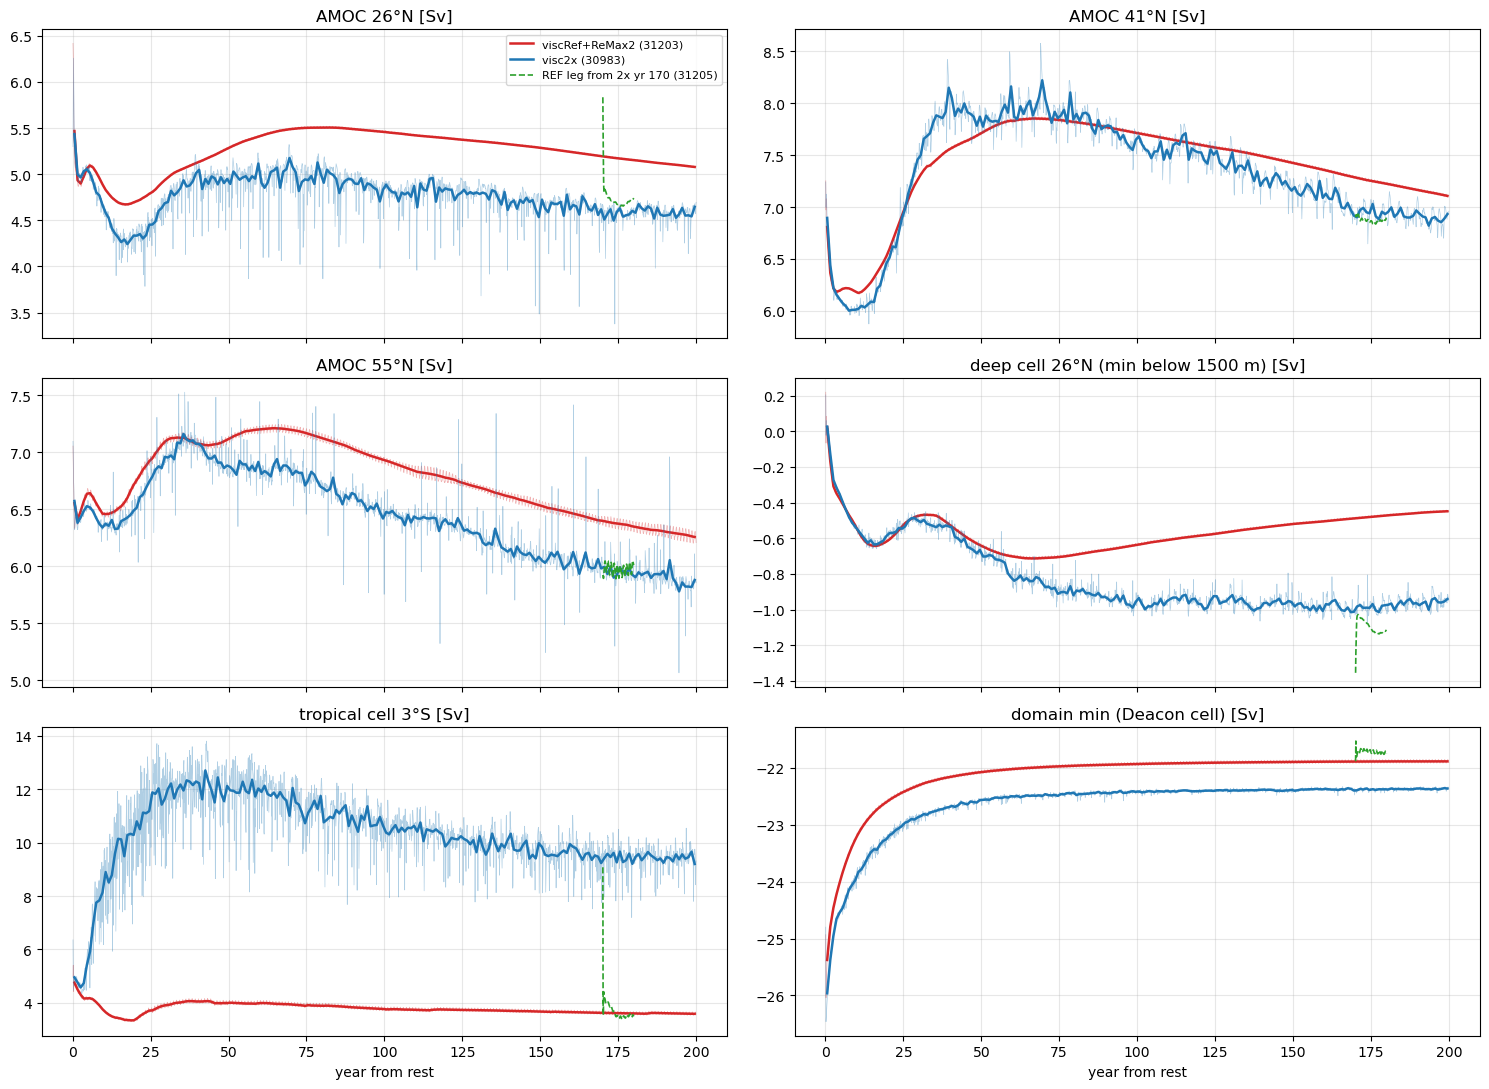

In [3]:
def moc_series(r, its=None):
    if its is None: its = iters_of(r)
    ds = xmitgcm.open_mdsdataset(r, grid_dir=r, prefix=['dynDiag'], geometry='curvilinear', delta_t=DT, iters=its, read_grid=True)
    tr = (ds.VVEL * ds.dxG * ds.drF * ds.hFacS).sum('i') / 1e6
    psi = tr.sortby('k', ascending=True).cumsum('k').transpose('time', 'k', 'j_g').values
    return dict(its=np.array(its), yrs=years(its), psi=psi, lat=ds.YC.isel(i=0).values, z=ds.Z.values)
def indices(d):
    lat, z, psi = d['lat'], d['z'], d['psi']; up = z >= -1000; deep = z <= -1500
    j = {p: int(np.abs(lat - p).argmin()) for p in (26, 41, 55, -3)}
    out = collections.OrderedDict((f'AMOC {p}°N', np.nanmax(psi[:, up, j[p]], axis=1)) for p in (26, 41, 55))
    out['deep cell 26°N (min below 1500 m)'] = np.nanmin(psi[:, deep, j[26]], axis=1)
    out['tropical cell 3°S'] = np.nanmax(psi[:, up, j[-3]], axis=1)
    out['domain min (Deacon cell)'] = np.nanmin(psi.reshape(len(psi), -1), axis=1)
    return out
D = {k: moc_series(run_dir[k]) for k in (NEW, OLD)}
D[LEG] = moc_series(run_dir[LEG]); D[LEG]['yrs'] = years(D[LEG]['its'])   # its already count from iteration 2986560 (year 170)
IDX = {k: indices(d) for k, d in D.items()}
fig, axs = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for ax, name in zip(axs.flat, IDX[NEW]):
    for k in (NEW, OLD):
        ax.plot(D[k]['yrs'], IDX[k][name], lw=0.5, color=COL[k], alpha=0.35)
        ya, va = annual(D[k]['yrs'], IDX[k][name]); ax.plot(ya, va, lw=1.8, color=COL[k], label=k)
    ax.plot(D[LEG]['yrs'], IDX[LEG][name], lw=1.2, color=COL[LEG], ls='--', label=LEG)
    ax.set_title(name + ' [Sv]'); ax.grid(alpha=.3)
for ax in axs[-1]: ax.set_xlabel('year from rest')
axs[0, 0].legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG_DIR + '/overturning_history_31203_vs_30983.png', dpi=110, bbox_inches='tight')
np.savez(OUT + '/overturning_series.npz', **{f'{lab}|{k}': v for k in IDX for lab, v in IDX[k].items()}, **{f'yrs|{k}': D[k]['yrs'] for k in D})
print(f"{'index':38s} {'run':30s} {'yr 10':>7s} {'yr 50':>7s} {'yr 100':>7s} {'yr 150':>7s} {'yr 170-180':>10s} {'yr 190-200':>10s} {'drift/decade 150-200':>20s}")
summ = {}
for name in IDX[NEW]:
    for k in (NEW, OLD, LEG):
        y, v = D[k]['yrs'], IDX[k][name]
        at = lambda y0, y1: np.nanmean(v[(y > y0) & (y <= y1)]) if ((y > y0) & (y <= y1)).any() else np.nan
        sl = np.polyfit(y[y > 150], v[y > 150], 1)[0] * 10 if (y > 150).sum() > 24 else np.nan
        summ[(name, k)] = dict(yr170_180=at(170, 180), yr190_200=at(190, 200), drift=sl)
        print(f'{name:38s} {k:30s} {at(9, 10):7.2f} {at(49, 50):7.2f} {at(99, 100):7.2f} {at(149, 150):7.2f} {at(170, 180):10.2f} {at(190, 200):10.2f} {sl:20.3f}')

## 3. The overturning cells in depth space

Decade means of ψ(y, z) for years 170–180 (the decade the adjoints' pickups come from) and 190–200 (the end state), both spin-ups and their difference.

decade     run                       AMOC26  AMOC41  AMOC55  z(max) 26N  zero 26N  deep 26N  trop 3S  psi min
170-180   viscRef+ReMax2 (31203)      5.17    7.25    6.37        -915     -2429     -0.48     3.61   -21.89
170-180   visc2x (30983)              4.57    6.95    5.95        -915     -2429     -0.99     9.44   -22.38
190-200   viscRef+ReMax2 (31203)      5.10    7.14    6.28        -915     -2429     -0.45     3.60   -21.89
190-200   visc2x (30983)              4.58    6.89    5.87        -915     -2429     -0.96     9.44   -22.37


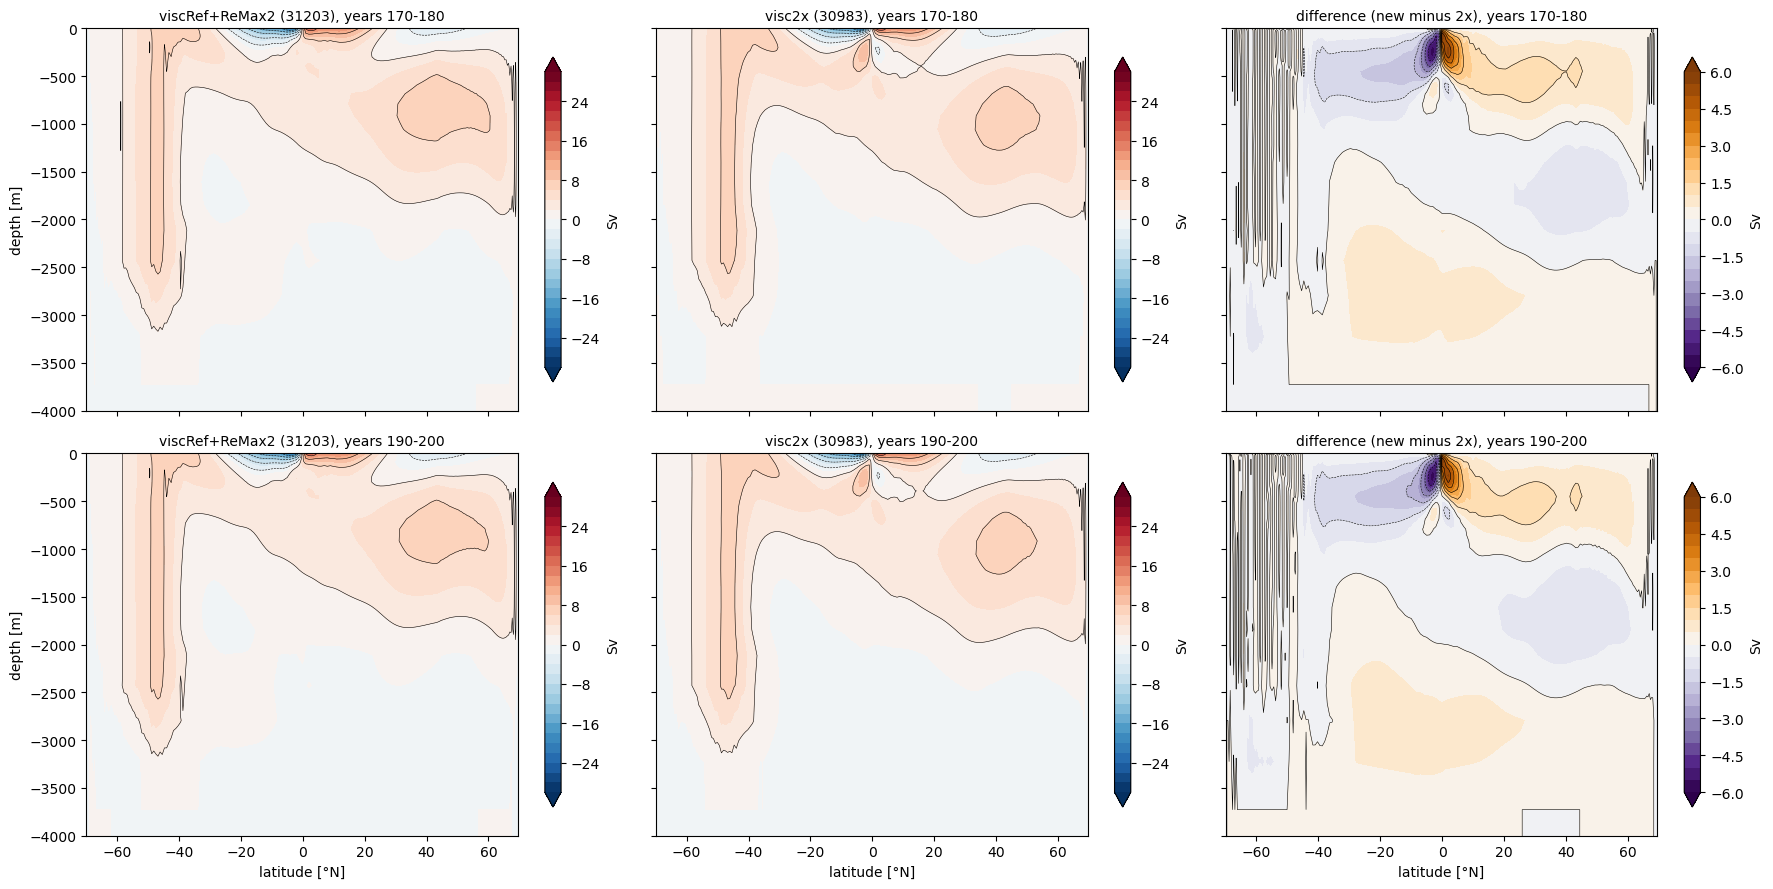

In [4]:
def decade(d, y0, y1): sel = (d['yrs'] > y0) & (d['yrs'] <= y1); return d['psi'][sel].mean(0)
lat, z = D[NEW]['lat'], D[NEW]['z']
fig, axs = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
lev = np.arange(-30, 31, 2)
for row, (y0, y1) in enumerate(((170, 180), (190, 200))):
    Pn, Po = decade(D[NEW], y0, y1), decade(D[OLD], y0, y1)
    for ax, P, t, lv, cm in ((axs[row, 0], Pn, f'{NEW}, years {y0}-{y1}', lev, 'RdBu_r'), (axs[row, 1], Po, f'{OLD}, years {y0}-{y1}', lev, 'RdBu_r'),
                             (axs[row, 2], Pn - Po, f'difference (new minus 2x), years {y0}-{y1}', np.arange(-6, 6.1, 0.5), 'PuOr_r')):
        cf = ax.contourf(lat, z, P, levels=lv, cmap=cm, extend='both'); ax.contour(lat, z, P, levels=lv[::2], colors='k', linewidths=0.4)
        ax.set_title(t, fontsize=10); ax.set_ylim(-4000, 0); plt.colorbar(cf, ax=ax, shrink=0.85, label='Sv')
for ax in axs[:, 0]: ax.set_ylabel('depth [m]')
for ax in axs[-1]: ax.set_xlabel('latitude [°N]')
fig.tight_layout(); fig.savefig(FIG_DIR + '/moc_depth_decades_31203_vs_30983.png', dpi=110, bbox_inches='tight')
j26 = int(np.abs(lat - 26).argmin()); jeq = int(np.abs(lat + 3).argmin())
print(f"{'decade':10s} {'run':24s} {'AMOC26':>7s} {'AMOC41':>7s} {'AMOC55':>7s} {'z(max) 26N':>11s} {'zero 26N':>9s} {'deep 26N':>9s} {'trop 3S':>8s} {'psi min':>8s}")
metrics = {}
for (y0, y1) in ((170, 180), (190, 200)):
    for k in (NEW, OLD):
        P = decade(D[k], y0, y1); up = z >= -1000
        kmax = int(np.nanargmax(np.where(up, P[:, j26], -np.inf)))
        kb = next((kk for kk in range(kmax, len(z)) if P[kk, j26] <= 0), len(z) - 1)
        m = dict(amoc26=float(np.nanmax(P[up, j26])), amoc41=float(np.nanmax(P[up, int(np.abs(lat - 41).argmin())])), amoc55=float(np.nanmax(P[up, int(np.abs(lat - 55).argmin())])),
                 zmax26=float(z[kmax]), zero26=float(z[kb]), deep26=float(np.nanmin(P[z <= -1500, j26])), trop=float(np.nanmax(P[up, jeq])), psimin=float(np.nanmin(P)))
        metrics[f'{y0}-{y1}|{k}'] = m
        print(f"{y0}-{y1:<5d} {k:24s} {m['amoc26']:7.2f} {m['amoc41']:7.2f} {m['amoc55']:7.2f} {m['zmax26']:11.0f} {m['zero26']:9.0f} {m['deep26']:9.2f} {m['trop']:8.2f} {m['psimin']:8.2f}")

## 4. Zonal-mean temperature and salinity, years 190–200

The end-state stratification of both spin-ups and the difference, zonally averaged with the wet-cell area weights.

viscRef+ReMax2 (31203)   Tmean 5.958 °C  T range [0.19, 27.34]  Smean 35.4780  S range [35.038, 37.000]
visc2x (30983)           Tmean 5.891 °C  T range [0.10, 27.65]  Smean 35.5276  S range [35.021, 37.003]
zonal-mean T difference: rms 0.458 K, max |dT| 1.88 K


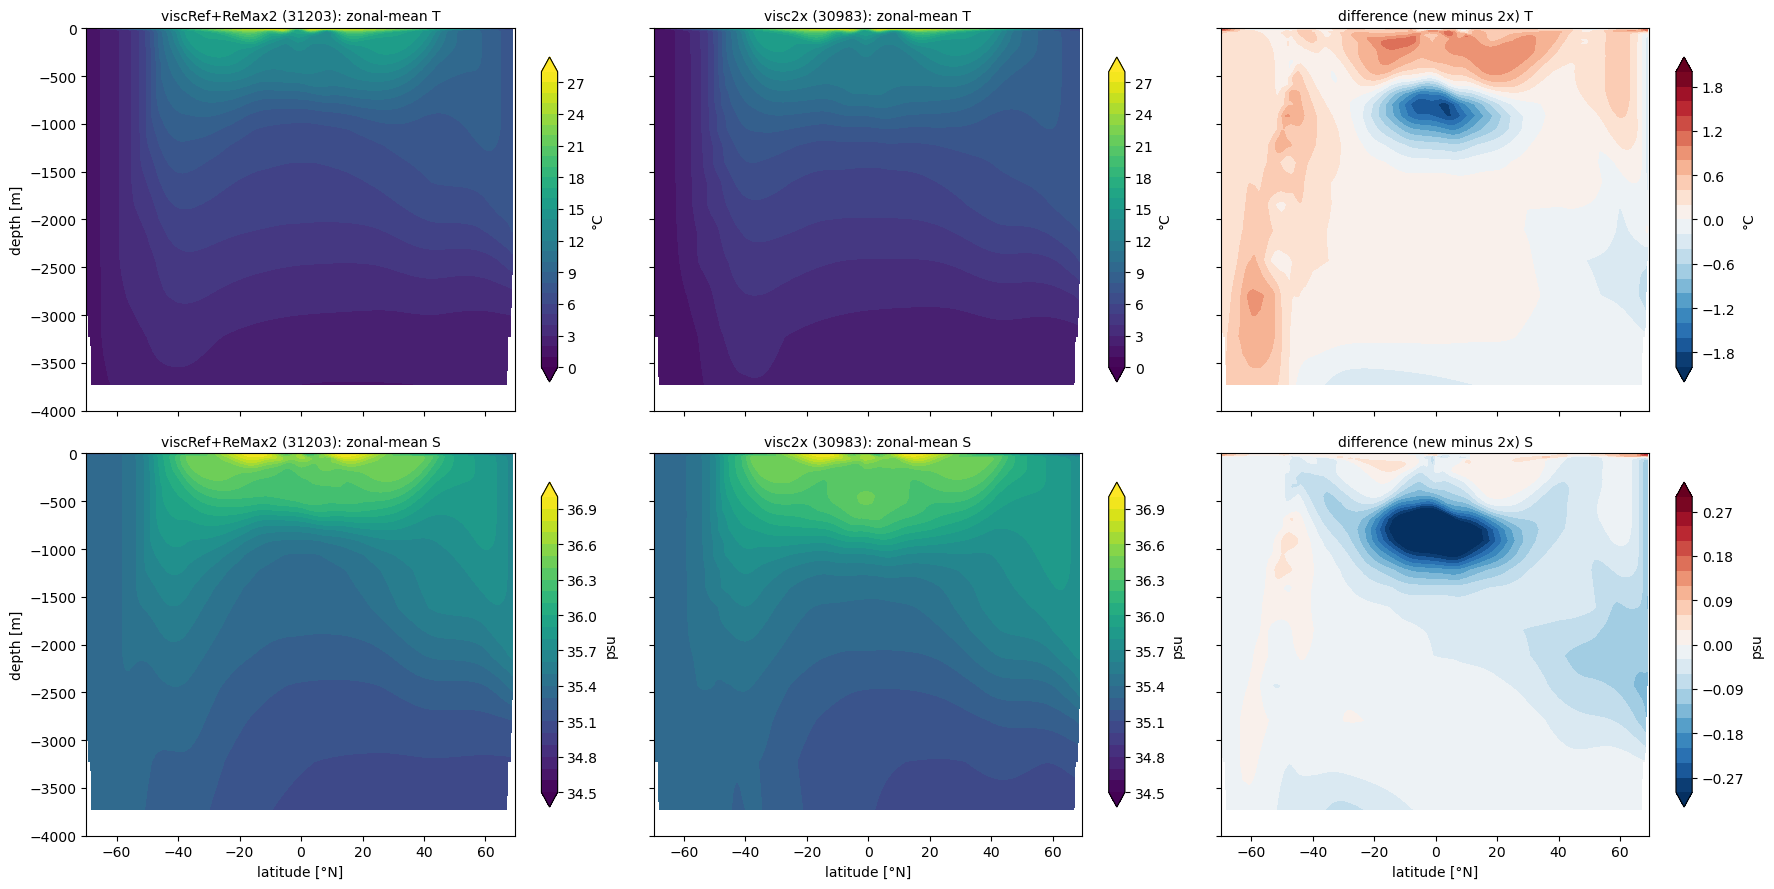

In [5]:
def zonal_mean_TS(r, y0, y1):
    its = [i for i in iters_of(r) if y0 < i / STEPS_PER_YR <= y1]
    ds = xmitgcm.open_mdsdataset(r, grid_dir=r, prefix=['dynDiag'], geometry='curvilinear', delta_t=DT, iters=its, read_grid=True)
    w = ds.hFacC * ds.rA; vol = ds.hFacC * ds.drF * ds.rA
    T = ds.THETA.mean('time'); S = ds.SALT.mean('time')
    zm = lambda f: ((f * w).sum('i') / w.sum('i')).transpose('k', 'j').values
    return dict(T=zm(T), S=zm(S), Tmean=float((T * vol).sum() / vol.sum()), Smean=float((S * vol).sum() / vol.sum()),
                Tmin=float(T.where(ds.hFacC > 0).min()), Tmax=float(T.where(ds.hFacC > 0).max()), Smin=float(S.where(ds.hFacC > 0).min()), Smax=float(S.where(ds.hFacC > 0).max()))
ZM = {k: zonal_mean_TS(run_dir[k], 190, 200) for k in (NEW, OLD)}
fig, axs = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
for row, (f, lv, dl, unit) in enumerate((('T', np.arange(0, 28.1, 1), np.arange(-2, 2.01, 0.2), '°C'), ('S', np.arange(34.5, 37.01, 0.1), np.arange(-0.3, 0.301, 0.03), 'psu'))):
    for ax, P, t, l, cm in ((axs[row, 0], ZM[NEW][f], f'{NEW}: zonal-mean {f}', lv, 'viridis'), (axs[row, 1], ZM[OLD][f], f'{OLD}: zonal-mean {f}', lv, 'viridis'),
                            (axs[row, 2], ZM[NEW][f] - ZM[OLD][f], f'difference (new minus 2x) {f}', dl, 'RdBu_r')):
        cf = ax.contourf(lat, z, P, levels=l, cmap=cm, extend='both'); ax.set_title(t, fontsize=10); ax.set_ylim(-4000, 0); plt.colorbar(cf, ax=ax, shrink=0.85, label=unit)
for ax in axs[:, 0]: ax.set_ylabel('depth [m]')
for ax in axs[-1]: ax.set_xlabel('latitude [°N]')
fig.tight_layout(); fig.savefig(FIG_DIR + '/zonal_mean_TS_yr190-200_31203_vs_30983.png', dpi=110, bbox_inches='tight')
for k in (NEW, OLD): print(f"{k:24s} Tmean {ZM[k]['Tmean']:.3f} °C  T range [{ZM[k]['Tmin']:.2f}, {ZM[k]['Tmax']:.2f}]  Smean {ZM[k]['Smean']:.4f}  S range [{ZM[k]['Smin']:.3f}, {ZM[k]['Smax']:.3f}]")
dT = ZM[NEW]['T'] - ZM[OLD]['T']; print(f'zonal-mean T difference: rms {np.sqrt(np.nanmean(dT**2)):.3f} K, max |dT| {np.nanmax(np.abs(dT)):.2f} K')

## 5. Mixed-layer depth, years 190–200

`MXLDEPTH` from `surfDiag`, decade mean: where the deep convection sits and how much of the basin it covers.

viscRef+ReMax2 (31203)   MLD mean 13 m, max 1297 m, area with MLD > 500 m: 0.5 %, > 1000 m: 0.0 %
visc2x (30983)           MLD mean 9 m, max 356 m, area with MLD > 500 m: 0.0 %, > 1000 m: 0.0 %


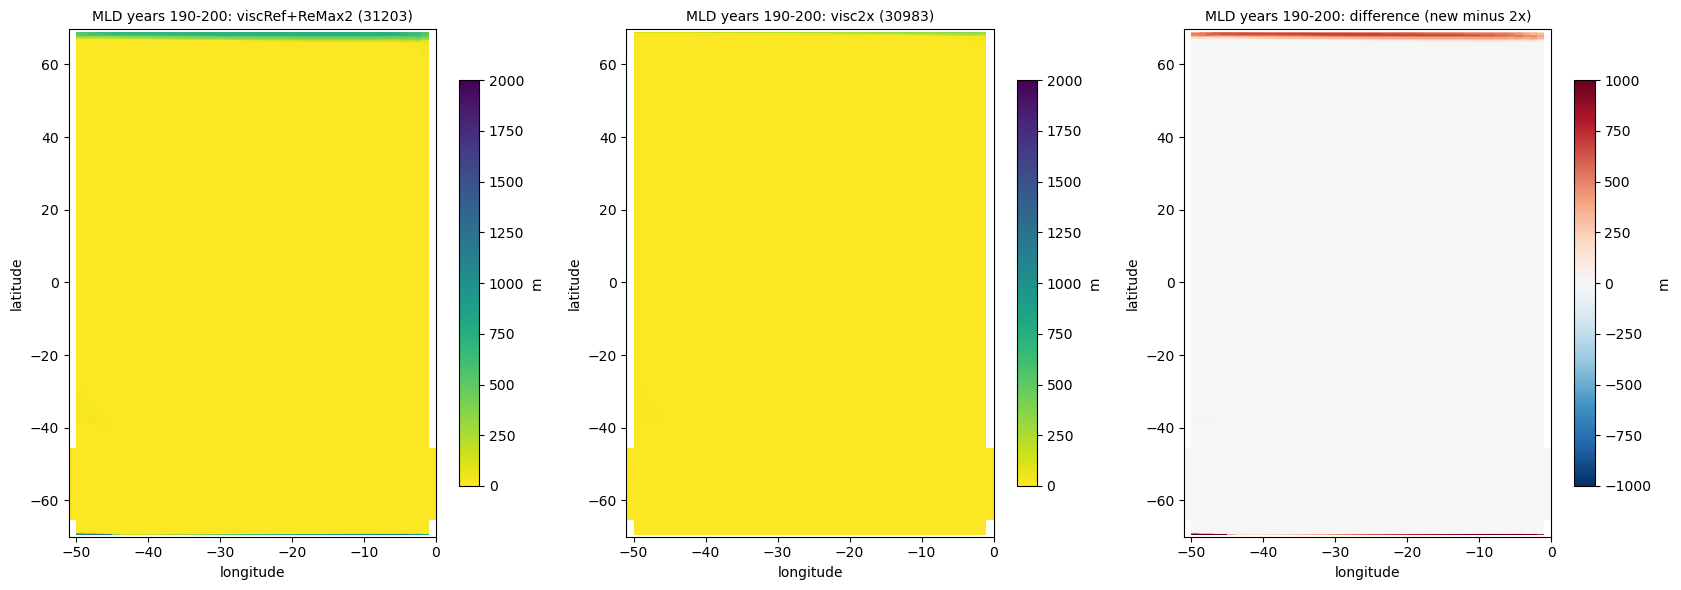

In [6]:
def mld(r, y0, y1):
    its = [i for i in iters_of(r, 'surfDiag') if y0 < i / STEPS_PER_YR <= y1]
    ds = xmitgcm.open_mdsdataset(r, grid_dir=r, prefix=['surfDiag'], geometry='curvilinear', delta_t=DT, iters=its, read_grid=True)
    m = ds.MXLDEPTH.mean('time'); wet = ds.hFacC.isel(k=0) > 0; a = ds.rA.where(wet)
    return dict(map=m.where(wet).values, XC=ds.XC.values, YC=ds.YC.values, mean=float((m * a).sum() / a.sum()),
                f500=float(a.where(m > 500).sum() / a.sum() * 100), f1000=float(a.where(m > 1000).sum() / a.sum() * 100), max=float(m.where(wet).max()))
ML = {k: mld(run_dir[k], 190, 200) for k in (NEW, OLD)}
fig, axs = plt.subplots(1, 3, figsize=(17, 6))
for ax, P, t, lv, cm in ((axs[0], ML[NEW]['map'], NEW, np.arange(0, 2001, 100), 'viridis_r'), (axs[1], ML[OLD]['map'], OLD, np.arange(0, 2001, 100), 'viridis_r'),
                         (axs[2], ML[NEW]['map'] - ML[OLD]['map'], 'difference (new minus 2x)', np.arange(-1000, 1001, 100), 'RdBu_r')):
    cf = ax.pcolormesh(ML[NEW]['XC'], ML[NEW]['YC'], P, vmin=lv[0], vmax=lv[-1], cmap=cm, shading='auto'); ax.set_title(f'MLD years 190-200: {t}', fontsize=10); plt.colorbar(cf, ax=ax, shrink=0.8, label='m')
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
fig.tight_layout(); fig.savefig(FIG_DIR + '/mld_yr190-200_31203_vs_30983.png', dpi=110, bbox_inches='tight')
for k in (NEW, OLD): print(f"{k:24s} MLD mean {ML[k]['mean']:.0f} m, max {ML[k]['max']:.0f} m, area with MLD > 500 m: {ML[k]['f500']:.1f} %, > 1000 m: {ML[k]['f1000']:.1f} %")

## 6. The year-180 state the adjoints start from

Two states carry that name now. The production adjoint 31204 starts from this spin-up's own year-180 pickup; 31206 and the kappa ensemble start from the reference leg 31205, which is the 2× spin-up's year-170 state integrated for 10 years under the new configuration. The panels compare the zonal-mean temperature of year 180 (12-month mean) between the three.

REF leg from 2x yr 170 (31205) minus viscRef+ReMax2 (31203): 3-D rms dT 0.399 K, zonal-mean rms 0.357 K, max |zonal-mean dT| 1.62 K
visc2x (30983)                 minus viscRef+ReMax2 (31203): 3-D rms dT 0.516 K, zonal-mean rms 0.461 K, max |zonal-mean dT| 1.93 K
AMOC 26°N    year 180 (12-month mean): viscRef+ReMax2 (31203) 5.17 Sv (decade 170-180), REF leg from 2x yr 170 (31205) 4.73 Sv (its year 180), visc2x (30983) 4.57 Sv (decade 170-180)
AMOC 41°N    year 180 (12-month mean): viscRef+ReMax2 (31203) 7.25 Sv (decade 170-180), REF leg from 2x yr 170 (31205) 6.88 Sv (its year 180), visc2x (30983) 6.95 Sv (decade 170-180)
AMOC 55°N    year 180 (12-month mean): viscRef+ReMax2 (31203) 6.37 Sv (decade 170-180), REF leg from 2x yr 170 (31205) 6.00 Sv (its year 180), visc2x (30983) 5.95 Sv (decade 170-180)
wrote /scratch2/tshahriar/DINO_1deg_outputs/analysis/spinup_200yr_viscRef_ReMax2/spinup_metrics.json


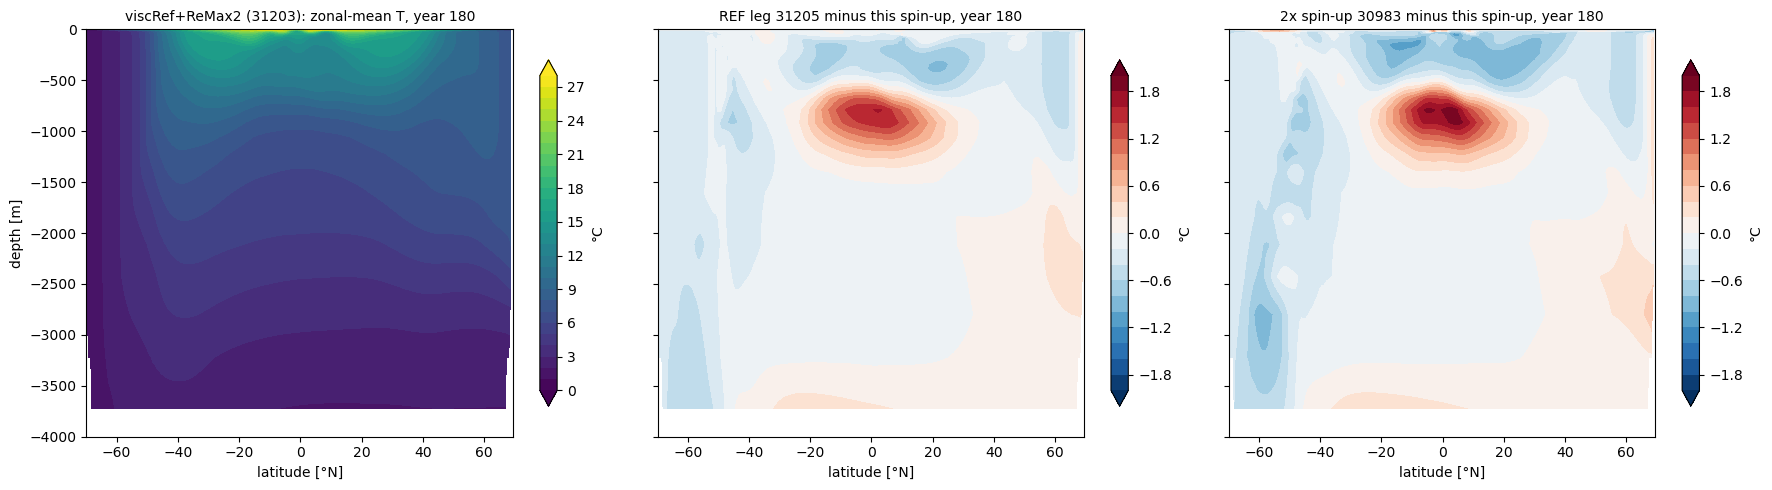

In [7]:
def zm_year(r, y0, y1):
    its = [i for i in iters_of(r) if y0 < i / STEPS_PER_YR <= y1]
    ds = xmitgcm.open_mdsdataset(r, grid_dir=r, prefix=['dynDiag'], geometry='curvilinear', delta_t=DT, iters=its, read_grid=True)
    w = ds.hFacC * ds.rA; T = ds.THETA.mean('time'); return ((T * w).sum('i') / w.sum('i')).transpose('k', 'j').values, T.where(ds.hFacC > 0)
T180 = {k: zm_year(run_dir[k], 179, 180) for k in (NEW, OLD, LEG)}
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, P, t, lv, cm in ((axs[0], T180[NEW][0], f'{NEW}: zonal-mean T, year 180', np.arange(0, 28.1, 1), 'viridis'),
                         (axs[1], T180[LEG][0] - T180[NEW][0], 'REF leg 31205 minus this spin-up, year 180', np.arange(-2, 2.01, 0.2), 'RdBu_r'),
                         (axs[2], T180[OLD][0] - T180[NEW][0], '2x spin-up 30983 minus this spin-up, year 180', np.arange(-2, 2.01, 0.2), 'RdBu_r')):
    cf = ax.contourf(lat, z, P, levels=lv, cmap=cm, extend='both'); ax.set_title(t, fontsize=10); ax.set_ylim(-4000, 0); ax.set_xlabel('latitude [°N]'); plt.colorbar(cf, ax=ax, shrink=0.85, label='°C')
axs[0].set_ylabel('depth [m]'); fig.tight_layout(); fig.savefig(FIG_DIR + '/state_yr180_31203_vs_REFleg31205_vs_30983.png', dpi=110, bbox_inches='tight')
for k in (LEG, OLD):
    d3 = (T180[k][1] - T180[NEW][1]); print(f'{k:30s} minus {NEW}: 3-D rms dT {float(np.sqrt((d3**2).mean())):.3f} K, zonal-mean rms {np.sqrt(np.nanmean((T180[k][0]-T180[NEW][0])**2)):.3f} K, max |zonal-mean dT| {np.nanmax(np.abs(T180[k][0]-T180[NEW][0])):.2f} K')
for name in list(IDX[NEW])[:3]:
    print(f"{name:12s} year 180 (12-month mean): {NEW} {summ[(name, NEW)]['yr170_180']:.2f} Sv (decade 170-180), {LEG} {np.nanmean(IDX[LEG][name][-12:]):.2f} Sv (its year 180), {OLD} {summ[(name, OLD)]['yr170_180']:.2f} Sv (decade 170-180)")
json.dump({'overturning': {k: {n: v for n, v in m.items()} for k, m in metrics.items()}, 'zonal_mean_yr190_200': {k: {q: ZM[k][q] for q in ('Tmean', 'Smean', 'Tmin', 'Tmax', 'Smin', 'Smax')} for k in ZM},
           'mld_yr190_200': {k: {q: ML[k][q] for q in ('mean', 'max', 'f500', 'f1000')} for k in ML}, 'drift_per_decade_150_200': {f'{a}|{b}': float(v) for (a, b), v in drift.items()},
           'series_summary': {f'{a}|{b}': v for (a, b), v in summ.items()}}, open(OUT + '/spinup_metrics.json', 'w'), indent=1, default=float)
print('wrote', OUT + '/spinup_metrics.json')

## 7. Forward reproducibility check

Run 31256: 10 years from rest under the live `input/data` with the same executable (`exe_md5 7b4d6732…`, built 2026-09-05), the standing check of CLAUDE.md's "Verifying correctness" item 1. Every `dynDiag`/`surfDiag`/`atmDiag`/`viscDiag` record of its 10 years must be byte-identical to the first 120 records of 31203.

In [8]:
hits = glob.glob(f'{RUNS}/*run31256') + glob.glob(f'{RUNS}/*/*run31256')
if not hits: print('31256: no run directory yet')
else:
    r = hits[0]; same = diff = missing = 0
    for f in sorted(glob.glob(r + '/*Diag.*.data')):
        g = run_dir[NEW] + '/' + os.path.basename(f)
        if not os.path.exists(g): missing += 1; continue
        if filecmp.cmp(f, g, shallow=False): same += 1
        else: diff += 1; print('DIFFERS', os.path.basename(f))
    print(f'31256 vs 31203: {same} diagnostic records identical, {diff} differ, {missing} not in 31203; 31256 has {len(iters_of(r))} dynDiag records (120 expected)')
    m1, m2 = mon(r + '/STDOUT.0000'), mon(run_dir[NEW] + '/STDOUT.0000')
    nd = sum(1 for i in m1 for q in m1[i] if m2.get(i, {}).get(q) != m1[i][q]); print(f'%MON values differing over the common {len(m1)} blocks: {nd}')

31256 vs 31203: 72 diagnostic records identical, 0 differ, 0 not in 31203; 31256 has 18 dynDiag records (120 expected)


%MON values differing over the common 19 blocks: 0


## Findings

- **The run completed without incident.** 200 years in 31 h 39 min; the kinetic energy settles by year 30 at 3.2e-4 m² s⁻² (the 2× run: 2.95e-4) and stays there; no burst in any monitor statistic. The volume-mean temperature still rises at 0.029 K per decade at year 200 (2×: 0.031) and the mean salinity at 0.008 per decade, so the abyss is not equilibrated in either run after 200 years; the circulation is.
- **Overturning.** Years 190–200: 5.1 Sv at 26° N, 7.1 at 41° N, 6.3 at 55° N, against 4.6 / 6.9 / 5.9 in the 2× run; the same history in both (a maximum between years 50 and 100, then a decline of 0.04 to 0.06 Sv per decade); the upper cell's maximum at 915 m and its zero crossing at 2429 m at 26° N in both. The deep cell at 26° N is half as strong (−0.45 against −0.96 Sv), the tropical cell at 3° S is a third (3.6 against 9.4 Sv) and the Deacon cell 0.5 Sv weaker (−21.9 against −22.4): the Reynolds floor `viscAhReMax=2.` acts where the flow is fastest, in the equatorial band, which is where the two overturnings differ (the ±6 Sv dipole in the upper 300 m of the difference panels). Poleward of 15° the cells have the same shape and vertical extent.
- **Variability.** The monthly indices of the new run are nearly free of the month-to-month spikes of the 2× run (up to ±0.5 Sv at 26° N and ±2 Sv in the tropical cell there), and its tracer extremes are steadier: in years 190–200 T lies in [0.19, 27.34] °C and S in [35.038, 37.000] (the 2× run: [0.10, 27.65], [35.021, 37.003], with monthly salinity maxima to 37.18 above the restoring maximum and winter minima of T to −0.55 °C).
- **Stratification.** Compared with the 2× state the new one is warmer in the upper 400 m of the tropics and subtropics by 0.5–1 K and colder below, by up to 1.9 K at 500–1000 m within 20° of the equator (zonal-mean rms 0.46 K), and fresher there by 0.3: a thinner, shallower tropical thermocline. The decade-mean mixed layer is shallow everywhere except along the northern wall (mean 13 m, maximum 1.3 km against 9 m and 356 m in the 2× run).
- **The year-180 state the campaign used.** The reference kappa leg 31205 (the 2× spin-up's year 170 integrated 10 years under the new configuration) differs from this spin-up's year 180 by 0.40 K rms in three dimensions and up to 1.6 K in the zonal mean at 700 m in the tropics; the 2× state itself differs by 0.52 K and 1.9 K. Ten years removed a quarter of the difference; the ensemble's and 31206's state carries the 2× spin-up's thick tropical thermocline. Its AMOC at year 180 is 4.7 Sv at 26° N against 5.2 in this spin-up. The production adjoint 31204 on this spin-up's own state, compared with 31206, measures what that inheritance does to the pathways.
- **Reproducibility.** The 10-yr run 31256 (same executable, same namelist) reproduces 31203 byte for byte: every diagnostic record and every `%MON` value it had written when this notebook last ran (see the cell above for the count; the run finishes about 1.6 h after submission).
